In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 실습 1. 데이터 불러오기와 단일 설비 센서 그리기
엔진 한 대를 골라 센서를 시간순으로 그리기

목표
- 데이터를 불러와 구조를 확인하고 엔진 한 대를 골라 센서를 시간순으로 그리기

단계
- 파일을 불러와 크기와 엔진 목록 확인
- 2번 엔진만 골라 회차 순으로 정렬
- 센서 하나를 시간순 선 그래프로 그리기

예상 결과
- 전체 1036행·엔진 5대, 2번 엔진 287행; 센서 곡선이 그려짐

(1250, 7)
(1250, 7) [1 2 3 4 5]
(250, 7)


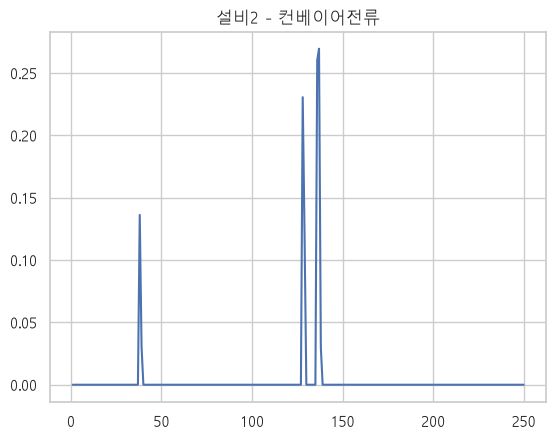

In [ ]:
# 파일 불러와 크기와 엔진 목록 확인
df = pd.read_csv("23_전기Panel.csv")
print(df.shape) # (1250, 7)

# 2번 엔진만 골라 회차 순으로 정렬
eng2 = df[df['설비번호'] == 2].copy().sort_values('시퀀스').reset_index(drop=True)
print(df.shape, df['설비번호'].unique())       # (1250, 7) [1 2 3 4 5]
print(eng2.shape)                                # (250, 7)

# 센서 하나를 시간순 선 그래프로 그리기
plt.plot(eng2['시퀀스'], eng2['컨베이어전류'])
plt.title('설비2 - 컨베이어전류')
plt.show()

## 실습 2. 단일 센서 이동평균 추적
창 크기 10 이동평균을 원본에 겹쳐 추세 읽기

목표
- 창 크기 10 이동평균을 구해 원본 위에 겹쳐 추세를 읽기

단계
- 센서에 창 크기 10 이동평균을 새 열로 담기
- 원본을 옅게, 이동평균을 진하게 겹쳐 그리기
- 이동평균선이 추세를 드러냄을 확인

예상 결과
- 들쭉날쭉한 원본 위로 매끈한 이동평균 추세선

[nan, nan, nan, nan, nan, nan, nan, nan, nan, 0.0, 0.0]


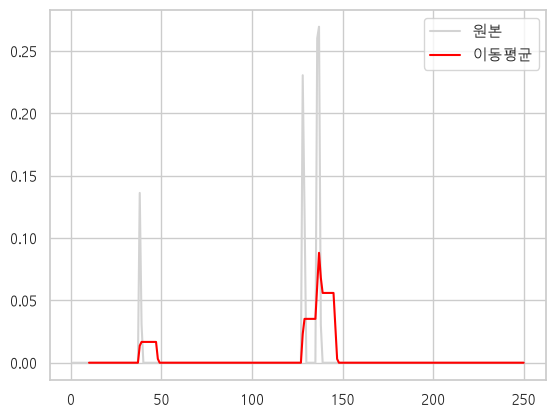

In [ ]:
eng2['ma10'] = eng2['컨베이어전류'].rolling(window=10).mean()
print(eng2['ma10'].head(11).round(4).tolist())    # 앞 9개 nan

# 원본 옅게
plt.plot(eng2['시퀀스'], eng2['컨베이어전류'], color='lightgray', label='원본')
# 이동평균 진하게
plt.plot(eng2['시퀀스'], eng2['ma10'], color='red', label='이동평균')
plt.legend()
plt.show()

## 실습 3. 창 크기 3종 비교
창 크기를 바꿔 매끈함과 반응성의 맞교환 비교

목표
- 창 크기를 5·10·30으로 바꿔 매끈함과 반응성의 맞교환을 비교

단계
- 세 가지 창 크기로 이동평균을 각각 구하기
- 세 이동평균을 한 그래프에 겹쳐 그리기
- 창이 클수록 매끄럽지만 반응이 느려짐을 확인

예상 결과
- 창이 클수록 곡선이 매끄럽고 앞쪽 빈 구간이 늘어남

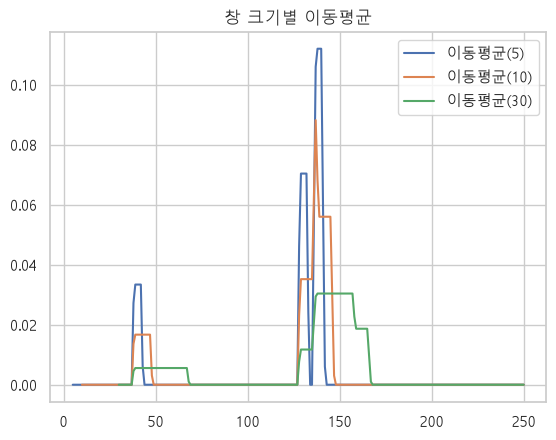

In [ ]:
for w in [5, 10, 30]:
    eng2[f'이동평균{w}'] = eng2['컨베이어전류'].rolling(window=w).mean()
    plt.plot(eng2['시퀀스'], eng2[f'이동평균{w}'], label=f'이동평균({w})')

plt.legend()
plt.title('창 크기별 이동평균')
plt.show()

## 실습 4. 이동평균·이동표준편차 동시 추적
추세와 변동성을 함께 계산해 동시에 추적

목표
- 이동평균과 이동표준편차를 함께 계산해 추세와 변동성을 동시에 추적

단계
- 창 크기 10으로 이동평균과 이동표준편차를 구하기
- 두 통계를 위아래 두 칸으로 나눠 그리기
- 초반과 후반의 변동성 평균을 비교

예상 결과
- 후반 변동성이 초반의 약 2배(5.5 → 9.5)로 커짐

초반/후반 변동성: 0.011 0.0


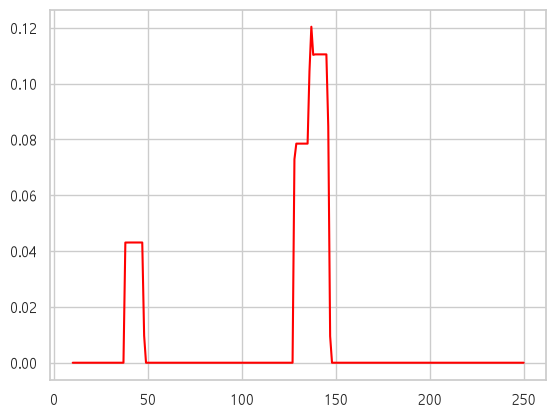

In [ ]:
eng2['std10'] = eng2['컨베이어전류'].rolling(10).std()
early = eng2['std10'].iloc[10:50].mean()
late = eng2['std10'].iloc[150:].mean()
print('초반/후반 변동성:', round(early, 4), round(late, 4))
# 초반/후반 변동성: 0.011 0.0

plt.plot(eng2['시퀀스'], eng2['std10'], color='red', label='STD(10)')
plt.show()

## 실습 5. 변화량·변화율 계산과 시각화
급변을 포착하고 이동평균 후 변화량으로 잡음 줄이기

목표
- 변화량과 변화율로 급변을 포착하고 이동평균 후 변화량으로 잡음을 줄이기

단계
- 직전 대비 변화량과 변화율을 각각 구하기
- 앞부분 값을 확인해 첫 값이 비는 이유 이해
- 이동평균을 먼저 낸 뒤 변화량을 구해 잡음이 줄어듦을 확인

예상 결과
- 변화량 앞부분 -0.43·3.07…, 첫 값은 비교 대상이 없어 빈 값

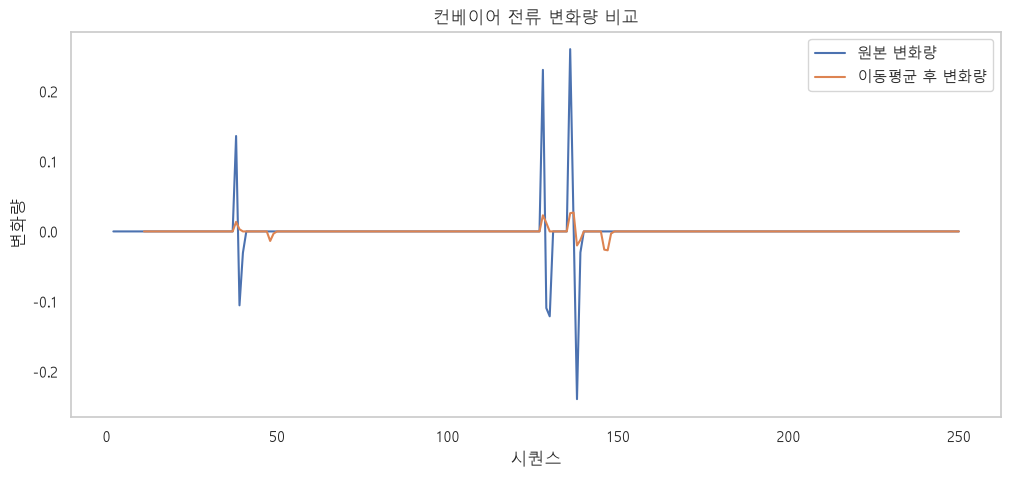

In [ ]:
eng2['diff'] = eng2['컨베이어전류'].diff()
eng2['pct'] = eng2['컨베이어전류'].pct_change()
eng2['ma10_diff'] = eng2['ma10'].diff()
eng2.tail()

# 그래프 1. 원본 변화량 vs 이동평균 후 변화량

plt.figure(figsize=(12, 5))

plt.plot(
    eng2["시퀀스"],
    eng2["diff"],
    label="원본 변화량"
)

plt.plot(
    eng2["시퀀스"],
    eng2["ma10_diff"],
    label="이동평균 후 변화량"
)

plt.xlabel("시퀀스")
plt.ylabel("변화량")
plt.title("컨베이어 전류 변화량 비교")
plt.legend()
plt.grid()

plt.show()

## 실습 6. 단순 변화점 탐지와 구간 표시
### 목표
잔차와 임계값으로 변화점을 찾고 그래프에 세로선으로 표시
### 단계
- 원본에서 이동평균을 뺀 잔차를 구하기
- 잔차 표준편차의 두 배를 임계값으로 정해 변화점 표시
- 변화점 위치를 세로선으로 그래프에 표시
### 예상 결과
임계값 약 16.3, 변화점 13개; 대부분 후반부에 몰림

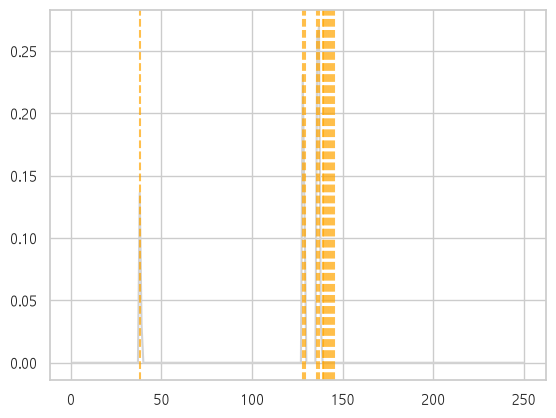

In [ ]:
roll = eng2['컨베이어전류'].rolling(10).mean()
resid = eng2['컨베이어전류'] - roll

# 잔차 표준편차의 두배를 임계값으로 정함
thr = 2 * resid.std()
# 변화점을 찾기
eng2["is_change"] = resid.abs() > thr

plt.plot(eng2['시퀀스'], eng2['컨베이어전류'], color='lightgray')

for c in eng2.loc[eng2['is_change'], '시퀀스']:
    plt.axvline(c, color='orange', linestyle='--', alpha=0.7)

plt.show()

## 실습 7. window·기준값 바꿔 결과 비교
### 목표
창 크기와 임계 배수를 바꿔 변화점 개수가 어떻게 달라지는지 비교
### 단계
· 잔차 기반 변화점 개수를 세는 함수를 만들기
· 창 크기를 바꿔 가며 변화점 개수 비교
· 임계 배수를 바꿔 가며 변화점 개수 비교
### 예상 결과
창이 커지거나 배수가 작아질수록 변화점 개수가 달라짐

In [ ]:
series = eng2['컨베이어전류']

k = 2

for window in [5, 10, 20]:
    r = series - series.rolling(window).mean()
    print("window: ", window, int((r.abs() > k * r.std()).sum()))
# window:  5 11
# window:  10 12
# window:  20 5

window = 10

for k in [1.5, 2.0, 3.0]:
    r = series - series.rolling(window).mean()
    print("k: ", k, int((r.abs() > k * r.std()).sum()))
# k:  1.5 12
# k:  2.0 12
# k:  3.0 5

window:  5 11
window:  10 12
window:  20 5
k:  1.5 12
k:  2.0 12
k:  3.0 5


## 실습 8. 단일 설비 상태 추적 미니 통합
### 목표
이동통계·변화점·변동성을 한데 모아 한 엔진의 상태를 요약
### 단계
- 이동평균·이동표준편차·변화점을 한 번에 계산
- 초반·후반 변동성과 변화점 개수를 요약
- 후반 변화점 비율로 상태를 한 문장으로 진단
### 예상 결과
후반 변동성이 커지고 변화점 13개, 후반 비율이 높아 열화 진행

In [ ]:
series = eng2['컨베이어전류']
window = 10

eng2['ma'] = series.rolling(window).mean() # 이동평균
eng2['std'] = series.rolling(window).std() # 이동표준편차

resid = series - eng2['ma']
thr = 2 * resid.std()               # 잔차 표준편차의 두배를 임계값으로 정함
eng2['chg'] = resid.abs() > thr    # 변화점을 찾기
half = eng2['시퀀스'].median()

print("전반부 변동성")
print("이동표준편차", round(eng2['std'].iloc[10:50].mean(), 4)) # 이동표준편차 0.011
print("------------------")
print("후반부 변동성")
print("이동표준편차", round(eng2['std'].iloc[150:].mean(), 4)) # 이동표준편차 0.0

print("------------------")
print("변화점: ", int(eng2['chg'].sum()))
print("후반 비율: ", round(eng2.loc[eng2['시퀀스'] > half, 'chg'].mean(), 2))
# 변화점:  12
# 후반 비율:  0.09


전반부 변동성
이동표준편차 0.011
------------------
후반부 변동성
이동표준편차 0.0
------------------
변화점:  12
후반 비율:  0.09
